In [1]:
include("../src/IndexingCombinationsSamples/Interpolations.jl")
using .QInterpolations 
using Plots

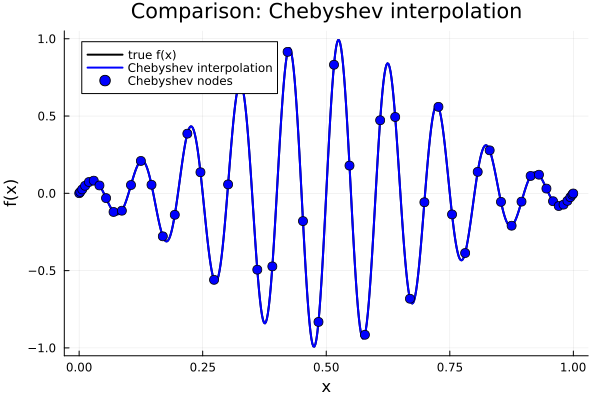

In [2]:
how_many = 50
ρ(x) = exp(-((x - 0.5) / 0.15)^2 / 2)   # Gaussian pdf centered at 0.5
f(x) = sin(20π*x) * exp(-((x-0.5)/0.3)^2)  # smooth test function

# --- Interpolators ---
inter_cheb = Interpolator(:chebychev, [(how_many, 0, 1)]; pdfs=ρ, endpoints=false)

# --- Function values at nodes ---
nodes_cheb = nodes(inter_cheb, separate=true)[1]
values_cheb = f.(nodes_cheb)

# --- Evaluate both interpolations on a dense grid ---
xs = collect(0:0.002:1)
vals_cheb = [eval_interpolation(inter_cheb, [x], values_cheb) for x in xs]

# --- Plot comparison ---
plt = plot(xs, f.(xs), lw=2, color=:black, label="true f(x)")
plot!(plt, xs, vals_cheb, lw=2, color=:blue, label="Chebyshev interpolation")

# --- Plot node positions ---
scatter!(plt, nodes_cheb, values_cheb, color=:blue, ms=5, label="Chebyshev nodes")

# --- Styling ---
plot!(plt, xlabel="x", ylabel="f(x)", xlims=:tight, ylims=:tight,
      title="Comparison: Chebyshev interpolation")
# legend top left 
plot!(plt, legend=:topleft) 
display(plt)


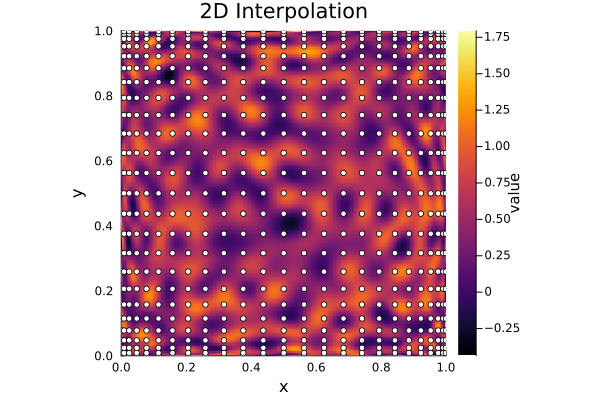

In [3]:
# Create a 2D interpolator over [0,1]×[0,1]
n1, n2 = 25, 25
inter = Interpolator(:chebychev, [(n1, 0, 1), (n2, 0, 1)], endpoints=false)
values = rand(n1, n2)  # node values

# Evaluation grid
xs = range(0, 1, length=250)
ys = range(0, 1, length=250)

vals = [eval_interpolation(inter, [x, y], values) for y in ys, x in xs]

# Plot 2D interpolation as heatmap
ax = heatmap(xs, ys, vals, xlabel="x", ylabel="y", aspect_ratio=1,
        colorbar_title="value", title="2D Interpolation")

node_pos = nodes(inter, separate=true)
scatter!(ax, node_pos[1], node_pos[2], color=:white, ms=3, label=nothing)
# tight limits 
xlims!(ax, minimum(xs), maximum(xs))
ylims!(ax, minimum(ys), maximum(ys))


In [4]:
basis_values(inter, [0.325, 0.231])

25×25 Matrix{Float64}:
  9.85424e-6   -3.04491e-5    5.40113e-5   …   8.89842e-6   -2.95126e-6
 -3.01393e-5    9.31291e-5   -0.000165195     -2.72159e-5    9.02647e-6
  5.22864e-5   -0.000161562   0.000286583      4.72149e-5   -1.56593e-5
 -7.80457e-5    0.000241157  -0.00042777      -7.04756e-5    2.3374e-5
  0.000110238  -0.00034063    0.000604217      9.95453e-5   -3.30153e-5
 -0.00015416    0.000476346  -0.000844953  …  -0.000139207   4.61695e-5
  0.000221602  -0.000684739   0.00121461       0.000200107  -6.63679e-5
 -0.000346015   0.00106917   -0.00189652      -0.000312453   0.000103628
  0.000676418  -0.0020901     0.00370747       0.000610808  -0.000202581
 -0.00521715    0.0161207    -0.0285953       -0.00471111    0.00156249
  ⋮                                        ⋱                
 -0.000107148   0.000331081  -0.00058728      -9.67549e-5    3.20898e-5
  8.77357e-5   -0.000271099   0.000480882      7.92257e-5   -2.62761e-5
 -7.16606e-5    0.000221428  -0.000392774     -6.47

In [ ]:
node_functionals_quadgk_array(inter, )

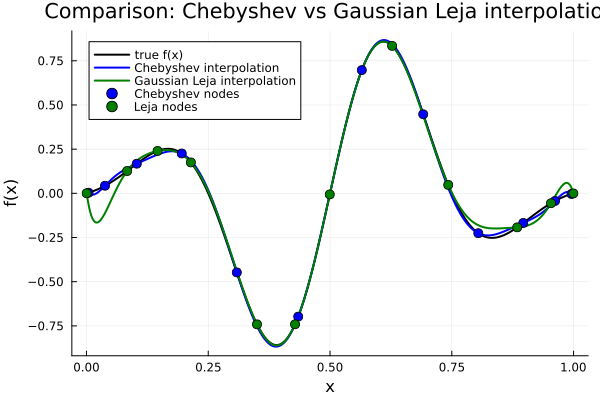

In [ ]:
how_many = 12
ρ(x) = exp(-((x - 0.5) / 0.15)^2 / 2)   # Gaussian pdf centered at 0.5
f(x) = sin(4π*x) * exp(-((x-0.5)/0.3)^2)  # smooth test function

# --- Interpolators ---
inter_cheb = Interpolator(:chebychev, [(how_many, 0, 1)]; pdfs=ρ, endpoints=false)
inter_leja = Interpolator(:fekete, [(how_many, 0, 1)]; pdfs=ρ, endpoints=false)

# --- Function values at nodes ---
nodes_cheb = nodes(inter_cheb, separate=true)[1]
nodes_leja = nodes(inter_leja, separate=true)[1]
values_cheb = f.(nodes_cheb)
values_leja = f.(nodes_leja)

# --- Evaluate both interpolations on a dense grid ---
xs = collect(0:0.002:1)
vals_cheb = [eval_interpolation(inter_cheb, [x], values_cheb) for x in xs]
vals_leja = [eval_interpolation(inter_leja, [x], values_leja) for x in xs]

# --- Plot comparison ---
plt = plot(xs, f.(xs), lw=2, color=:black, label="true f(x)")
plot!(plt, xs, vals_cheb, lw=2, color=:blue, label="Chebyshev interpolation")
plot!(plt, xs, vals_leja, lw=2, color=:green, label="Gaussian Leja interpolation")

# --- Plot node positions ---
scatter!(plt, nodes_cheb, values_cheb, color=:blue, ms=5, label="Chebyshev nodes")
scatter!(plt, nodes_leja, values_leja, color=:green, ms=5, label="Leja nodes")

# --- Styling ---
plot!(plt, xlabel="x", ylabel="f(x)", xlims=:tight, ylims=:tight,
      title="Comparison: Chebyshev vs Gaussian Leja interpolation")
# legend top left 
plot!(plt, legend=:topleft) 
display(plt)


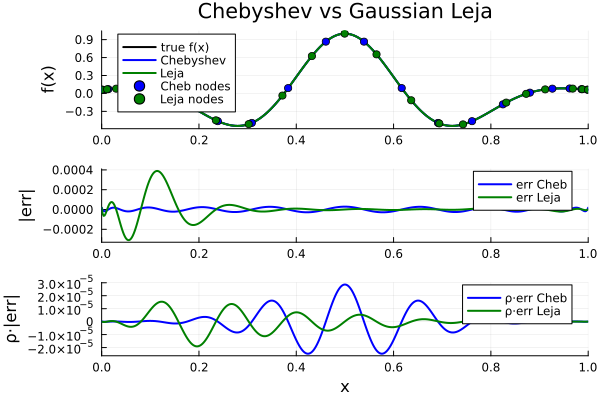

In [18]:
using Plots

how_many = 20
ρ(x) = exp(-((x - 0.5) / 0.15)^2 / 2)
f(x) = cos(4π*x) * exp(-((x-0.5)/0.3)^2)

# --- Interpolators ---
inter_cheb = Interpolator(:chebychev, [(how_many, 0, 1)]; pdfs=ρ, endpoints=false)
inter_leja = Interpolator(:fekete, [(how_many, 0, 1)]; pdfs=ρ, endpoints=false)

# --- Function values ---
nodes_cheb = nodes(inter_cheb, separate=true)[1]
nodes_leja = nodes(inter_leja, separate=true)[1]
values_cheb = f.(nodes_cheb)
values_leja = f.(nodes_leja)

# --- Evaluate on dense grid ---
xs = 0:0.002:1
vals_true = f.(xs)
vals_cheb = [eval_interpolation(inter_cheb, [x], values_cheb) for x in xs]
vals_leja = [eval_interpolation(inter_leja, [x], values_leja) for x in xs]

# --- Absolute errors ---
err_cheb = (vals_true .- vals_cheb)
err_leja = (vals_true .- vals_leja)
ρs = ρ.(xs)
weighted_err_cheb = err_cheb .* ρs
weighted_err_leja = err_leja .* ρs

# --- Layout ---
plt = plot(layout = @layout([a; b{0.3h}; c{0.3h}]))

# --- Top: interpolations ---
plot!(plt[1], xs, vals_true, lw=2, color=:black, label="true f(x)")
plot!(plt[1], xs, vals_cheb, lw=2, color=:blue, label="Chebyshev")
plot!(plt[1], xs, vals_leja, lw=2, color=:green, label="Leja")
scatter!(plt[1], nodes_cheb, values_cheb, color=:blue, ms=4, label="Cheb nodes")
scatter!(plt[1], nodes_leja, values_leja, color=:green, ms=4, label="Leja nodes")
plot!(plt[1], ylabel="f(x)", title="Chebyshev vs Gaussian Leja", legend=:topleft, xlims=(0,1))

# --- Middle: |error| ---
plot!(plt[2], xs, err_cheb, lw=2, color=:blue, label="err Cheb")
plot!(plt[2], xs, err_leja, lw=2, color=:green, label="err Leja")
plot!(plt[2], ylabel="|err|", legend=:topright, xlims=(0,1))

# --- Bottom: ρ·|error| ---
plot!(plt[3], xs, weighted_err_cheb, lw=2, color=:blue, label="ρ·err Cheb")
plot!(plt[3], xs, weighted_err_leja, lw=2, color=:green, label="ρ·err Leja")
plot!(plt[3], xlabel="x", ylabel="ρ·|err|", legend=:topright, xlims=(0,1))

display(plt)


In [19]:
println("Cummulative Error Chebychev: ", sum(err_cheb))
println("Cummulative Error Leja: ", sum(err_leja))

Cummulative Error Chebychev: 3.521526098552129e-7
Cummulative Error Leja: 0.0014456307185278234


In [20]:
println("Weighted Cummulative Error Chebychev: ", sum(weighted_err_cheb))
println("Weighted Cummulative Error Leja: ", sum(weighted_err_leja))

Weighted Cummulative Error Chebychev: 5.028321893855693e-8
Weighted Cummulative Error Leja: -4.238938644171188e-5


In [22]:
# test_weights.jl
using .Interpolations   # if you're in the same project; else `using Interpolations`
using Printf
using Random; Random.seed!(42)

# Gaussian pdf on [0,1]
ρ(x) = exp(-((x - 0.5)/0.18)^2 / 2)

n = 10
# Try a few grids
inter_cheb   = Interpolator(:chebychev, [(n, 0, 1)], endpoints=false)

# Compute weights (normalized so ∫ρ=1)
w_cheb   = integration_weights(inter_cheb;   pdfs=ρ, normalize=true)

x_cheb   = nodes(inter_cheb,   separate=true)[1]

println("== Sanity checks (weights should sum to ~1) ==")
@printf("chebyshev: sum(w)=%.16f\n", sum(w_cheb))

println("== Nodes and weights (chebyshev) ==")
for i in eachindex(x_cheb)
    @printf("[%2d] x=%.6f  w=%.8f\n", i, x_cheb[i], w_cheb[i])
end


UndefVarError: UndefVarError: `integration_weights` not defined in `Main`
Suggestion: check for spelling errors or missing imports.